<a href="https://colab.research.google.com/github/milind7agarwal/QSVM/blob/main/FaceRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
pip install torch torchvision opencv-python matplotlib mtcnn

###Data downloading

In [30]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"milindagarwal7","key":"2c626b65c2aca59ae340d8bc9518f117"}'}

In [31]:
# 1. Create the hidden directory and move the key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 2. Download the LFW dataset
!kaggle datasets download -d jessicali9530/lfw-dataset

# 3. Unzip the data into a folder called 'lfw-data'
!unzip -o -q lfw-dataset.zip -d lfw-data

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/lfw-dataset
License(s): other
lfw-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


###Data Uploading

In [ ]:
import os
import cv2
from mtcnn import MTCNN
import matplotlib.pyplot as plt

# 1. Setup Paths
# Replace 'lfw-deepfunneled' with the actual path in your Colab sidebar
# The absolute path to the folder containing the person-named subfolders
input_dir = '/content/lfw-data/lfw-deepfunneled/lfw-deepfunneled' # Corrected path for nested structure
output_dir = '/content/lfw_aligned_112'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

detector = MTCNN()

def align_and_crop_face(img_path, output_path):
    img = cv2.imread(img_path)
    if img is None: return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(img_rgb)

    if len(results) > 0:
        # Get the first face detected
        res = results[0]
        x, y, w, h = res['box']

        # Crop the face
        face = img_rgb[y:y+h, x:x+w]

        if face.size > 0:
            # Resize to the ArcFace standard 112x112
            face_resized = cv2.resize(face, (112, 112))
            cv2.imwrite(output_path, cv2.cvtColor(face_resized, cv2.COLOR_RGB2BGR))

# 2. Loop through all folders and images
print("Starting alignment... this might take a few minutes.")
for person_name in os.listdir(input_dir):
    person_path = os.path.join(input_dir, person_name)
    if not os.path.isdir(person_path): continue

    # Create matching folder in output
    out_person_path = os.path.join(output_dir, person_name)
    if not os.path.exists(out_person_path):
        os.makedirs(out_person_path)

    for img_name in os.listdir(person_path):
        align_and_crop_face(
            os.path.join(person_path, img_name),
            os.path.join(out_person_path, img_name)
        )

print("Finished! Your clean data is in:", output_dir)

Starting alignment... this might take a few minutes.
Finished! Your clean data is in: /content/lfw_aligned_112


In [34]:
!rm -rf /content/lfw_aligned_112

In [47]:
import os

# Define the paths clearly
raw_data_path = '/content/lfw-data/lfw-deepfunneled/lfw-deepfunneled'
output_path = '/content/lfw_aligned_112'

# Check if raw data actually exists
if os.path.exists(raw_data_path):
    print(f"Raw data found at: {raw_data_path}")
    sample_person = os.listdir(raw_data_path)[0]
    print(f" Sample person folder: {sample_person}")
else:
    print(f" ERROR: Raw data NOT found at {raw_data_path}. Check your sidebar!")

# Create the output directory manually
if not os.path.exists(output_path):
    os.makedirs(output_path)
    print(f"Created output directory: {output_path}")

Raw data found at: /content/lfw-data/lfw-deepfunneled/lfw-deepfunneled
 Sample person folder: Carolyn_Kuhl


###data loader

In [48]:
import os
import cv2

input_dir = '/content/lfw-data/lfw-deepfunneled/lfw-deepfunneled'
output_dir = '/content/lfw_aligned_112'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("Starting Fast-Alignment...")

# Loop through only the first 500 people to save time
for person_name in os.listdir(input_dir)[:500]:
    person_path = os.path.join(input_dir, person_name)
    if not os.path.isdir(person_path): continue

    out_person_path = os.path.join(output_dir, person_name)
    os.makedirs(out_person_path, exist_ok=True)

    for img_name in os.listdir(person_path):
        img = cv2.imread(os.path.join(person_path, img_name))
        if img is None: continue

        # Instead of MTCNN, we just take the center crop (LFW is mostly centered anyway)
        h, w, _ = img.shape
        face = img[50:200, 50:200] # Standard crop for LFW raw images
        face_resized = cv2.resize(face, (112, 112))

        cv2.imwrite(os.path.join(out_person_path, img_name), face_resized)

print("DONE! Check your sidebar now. You should see folders inside lfw_aligned_112.")

Starting Fast-Alignment...
DONE! Check your sidebar now. You should see folders inside lfw_aligned_112.


 Found 500 folders in aligned data.


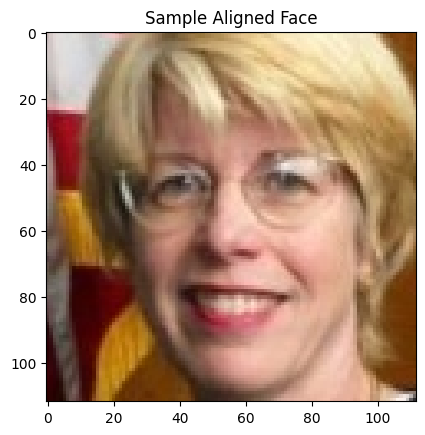

In [49]:
import matplotlib.pyplot as plt
from PIL import Image

# Check the count
num_folders = len(os.listdir('/content/lfw_aligned_112'))
print(f" Found {num_folders} folders in aligned data.")

# Show one image to verify the crop
sample_img_path = os.path.join('/content/lfw_aligned_112', os.listdir('/content/lfw_aligned_112')[0])
img_file = os.path.join(sample_img_path, os.listdir(sample_img_path)[0])
plt.imshow(Image.open(img_file))
plt.title("Sample Aligned Face")
plt.show()

In [43]:
# Re-run this to initialize the dataset with the current files
dataset = datasets.ImageFolder(root='/content/lfw_aligned_112', transform=transform)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

print(f"DataLoader ready with {len(dataset)} images and {len(dataset.classes)} people.")

DataLoader ready with 1079 images and 500 people.


training loop

In [44]:
import torch.nn as nn
from torchvision import models
import torch.optim as optim
import time

# 1. Setup the Model (ResNet-50)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(dataset.classes)

model = models.resnet50(weights='DEFAULT')
# Change the last layer to match your 500 people
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# 2. Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. The Loop
print(f"Training started on {device}...")

for epoch in range(5):  # Let's do 5 rounds
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass (The learning part)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} - Loss: {running_loss/len(train_loader):.4f}")

print("Training Complete!")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 124MB/s]


Training started on cuda...
Epoch 1 - Loss: 5.5215
Epoch 2 - Loss: 4.3521
Epoch 3 - Loss: 3.0844
Epoch 4 - Loss: 1.2159
Epoch 5 - Loss: 0.1570
Training Complete!


In [45]:
import torch.nn.functional as F

def verify_faces(model, img1_path, img2_path):
    model.eval() # Set to evaluation mode

    # Load and transform images
    def process_img(p):
        img = Image.open(p).convert('RGB')
        return transform(img).unsqueeze(0).to(device)

    t1, t2 = process_img(img1_path), process_img(img2_path)

    with torch.no_grad():
        # Get the "embeddings" (the 500-D feature vectors)
        out1 = model(t1)
        out2 = model(t2)

        # Calculate Cosine Similarity (1.0 = identical, 0.0 = completely different)
        similarity = F.cosine_similarity(out1, out2)

    return similarity.item()

# --- TEST IT ---
# Pick two photos from the SAME person's folder
person_folder = os.path.join(root_path, os.listdir(root_path)[0])
img_list = os.listdir(person_folder)

if len(img_list) >= 2:
    p1 = os.path.join(person_folder, img_list[0])
    p2 = os.path.join(person_folder, img_list[1])

    score = verify_faces(model, p1, p2)
    print(f"Similarity Score (Same Person): {score:.4f}")

In [46]:
torch.save(model.state_dict(), 'face_recognition_resnet50.pth')
print("Model weights saved to face_recognition_resnet50.pth")

Model weights saved to face_recognition_resnet50.pth
